# Projet de Régression — Prédiction des Prix Immobiliers

**Dataset** : Boston Housing (`housing.csv`)  
**Objectif :** Construire et comparer plusieurs modèles de régression pour prédire le prix médian des logements (`MEDV`) à partir de caractéristiques socio-économiques et géographiques.  
**Auteur :** Hassan Charaf 

## 1. Importation des bibliothèques

On importe l'ensemble des bibliothèques nécessaires : `pandas` et `numpy` pour la manipulation des données, `matplotlib` et `seaborn` pour la visualisation, `scipy` pour les tests statistiques, et `sklearn` / `statsmodels` pour la modélisation.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm

## 2. Chargement et Exploration des Données

On charge le fichier CSV en précisant les noms des 14 colonnes, puis on affiche les premières lignes pour vérifier la bonne lecture du jeu de données.

In [22]:
colonnes = ["CRIM","ZN","INDUS","CHAS","NOX","RM","AGE","DIS","RAD","TAX","PTRATIO","B","LSTAT","MEDV"]
donnees = pd.read_csv("data/housing.csv", sep=r"\s+", names = colonnes)
donnees.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


On vérifie l'absence de valeurs manquantes et de doublons avant toute analyse.

In [23]:
print("=== Valeurs manquantes par variable ===")
print(donnees.isnull().sum())
print(f"\nDoublons : {donnees.duplicated().sum()} ligne(s)")

=== Valeurs manquantes par variable ===
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Doublons : 0 ligne(s)


On calcule les statistiques descriptives (moyenne, écart-type, quartiles…) pour avoir une première vue d'ensemble de la distribution de chaque variable.

In [24]:
donnees.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


## 3. Analyse Statistique et Exploratoire (EDA)

### 3.1 Intervalles de confiance et Normalité

Pour chaque variable, on calcule l'intervalle de confiance à 95 % et on vérifie si la distribution suit une loi normale via le test de Shapiro-Wilk :

In [25]:
for colonne in donnees.columns:
    # 1. Calcul de l'intervalle de confiance à 95%
    moyenne = donnees[colonne].mean()
    ecart_type = donnees[colonne].std()
    n = len(donnees[colonne])
    z = 1.96
    
    erreur_std = z * (ecart_type / np.sqrt(n))
    ic_inf = moyenne - erreur_std
    ic_sup = moyenne + erreur_std
    
    print(f"--- {colonne} ---")
    print(f"Intervalle de confiance à 95% : [ {ic_inf:.2f} , {ic_sup:.2f} ]")
    
    # 2. Test de normalité (Shapiro-Wilk)
    stat, p_value = st.shapiro(donnees[colonne])
    print(f"Test de Shapiro-Wilk : stat = {stat:.4f}, p-value = {p_value:.4e}")
    
    if p_value > 0.05:
        print("-> Suit une distribution normale\n")
    else:
        print("-> NE suit PAS une distribution normale\n")

--- CRIM ---
Intervalle de confiance à 95% : [ 2.86 , 4.36 ]
Test de Shapiro-Wilk : stat = 0.4500, p-value = 1.3286e-36
-> NE suit PAS une distribution normale

--- ZN ---
Intervalle de confiance à 95% : [ 9.33 , 13.40 ]
Test de Shapiro-Wilk : stat = 0.5559, p-value = 7.8828e-34
-> NE suit PAS une distribution normale

--- INDUS ---
Intervalle de confiance à 95% : [ 10.54 , 11.73 ]
Test de Shapiro-Wilk : stat = 0.8998, p-value = 1.0647e-17
-> NE suit PAS une distribution normale

--- CHAS ---
Intervalle de confiance à 95% : [ 0.05 , 0.09 ]
Test de Shapiro-Wilk : stat = 0.2748, p-value = 2.3505e-40
-> NE suit PAS une distribution normale

--- NOX ---
Intervalle de confiance à 95% : [ 0.54 , 0.56 ]
Test de Shapiro-Wilk : stat = 0.9356, p-value = 5.7762e-14
-> NE suit PAS une distribution normale

--- RM ---
Intervalle de confiance à 95% : [ 6.22 , 6.35 ]
Test de Shapiro-Wilk : stat = 0.9609, p-value = 2.4120e-10
-> NE suit PAS une distribution normale

--- AGE ---
Intervalle de confiance

### 3.2 Visualisation des distributions

On affiche l'histogramme et la courbe de densité pour comprendre comment les données de chaque variable sont réparties :

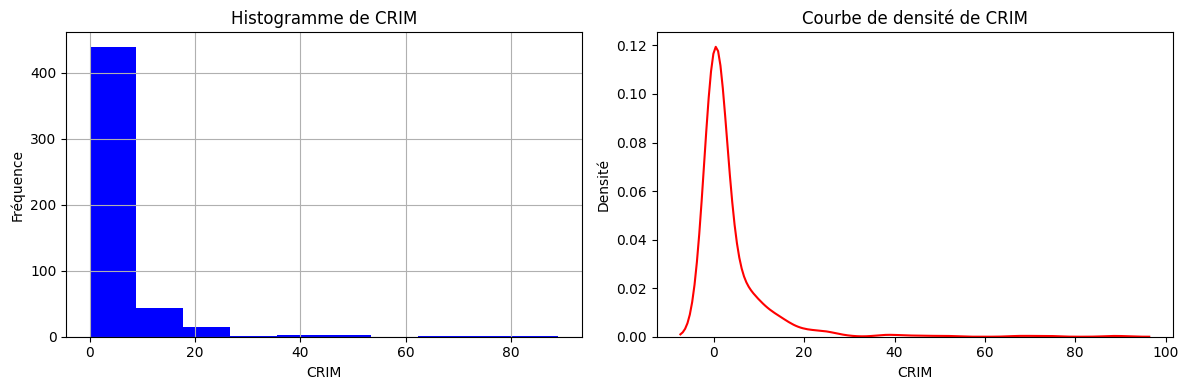

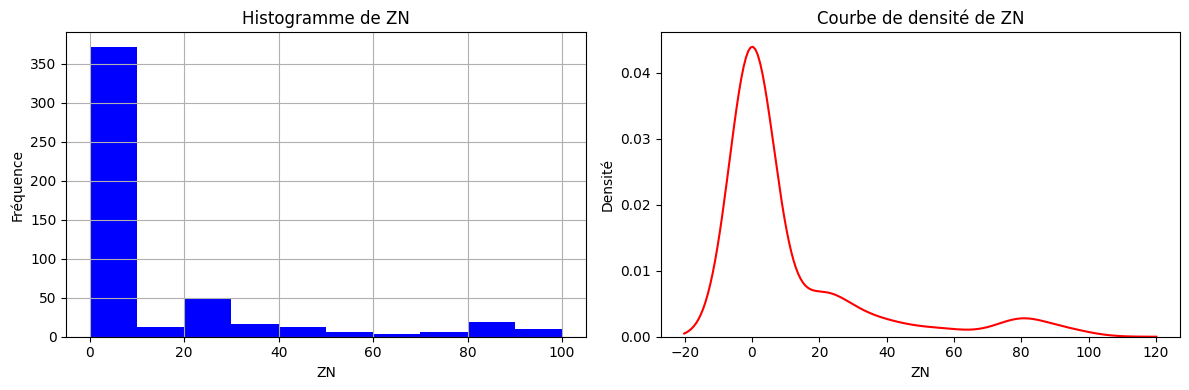

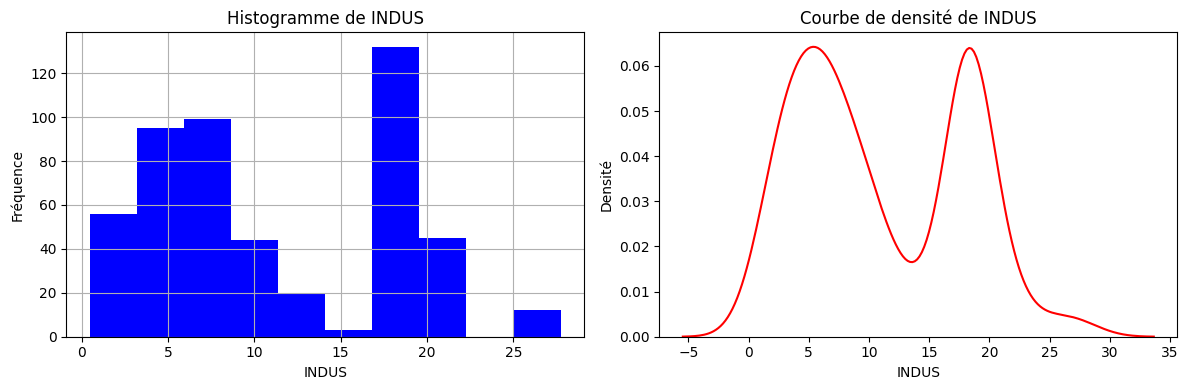

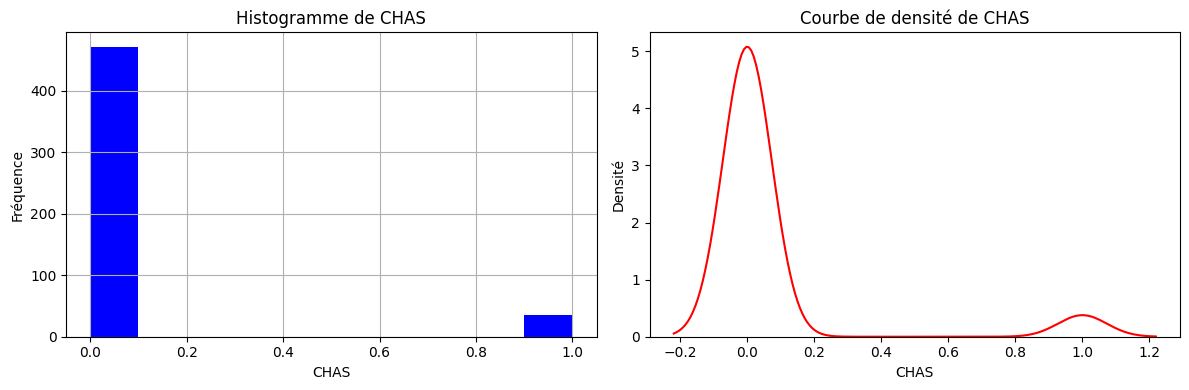

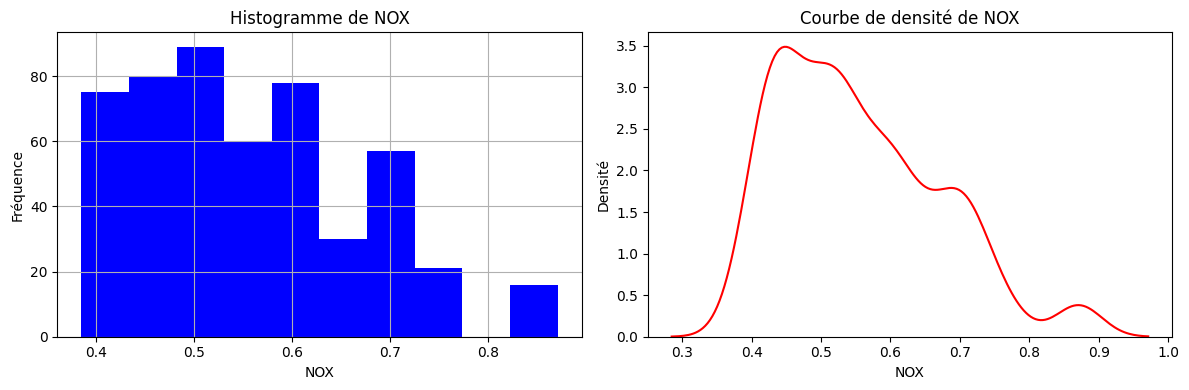

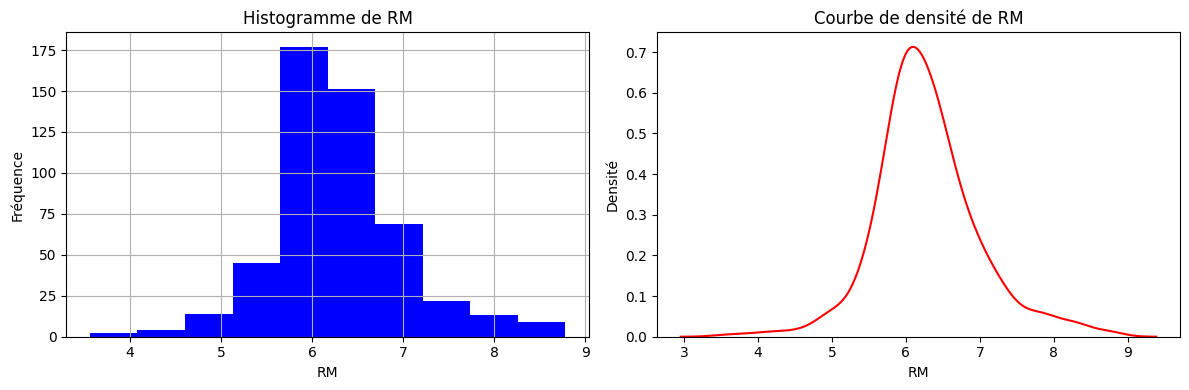

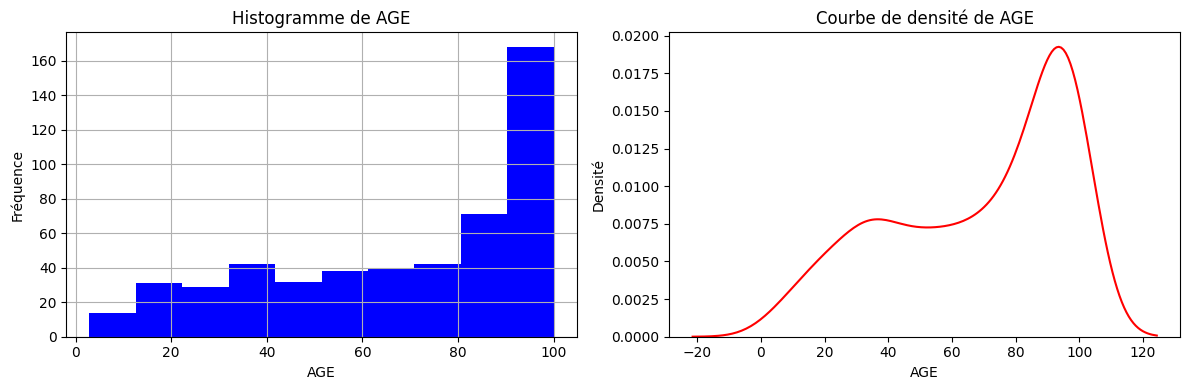

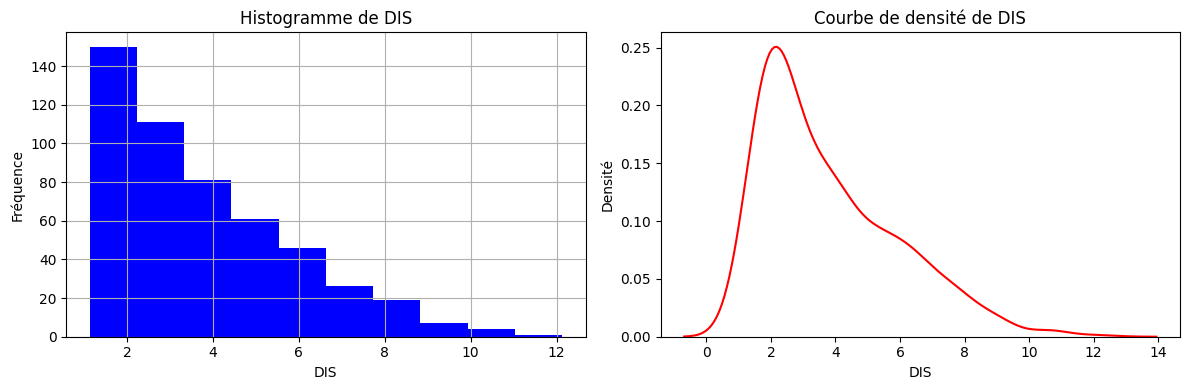

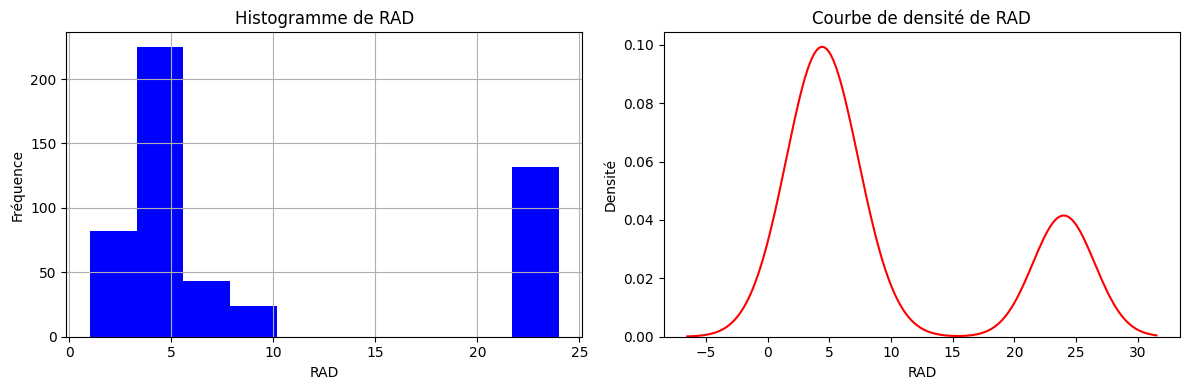

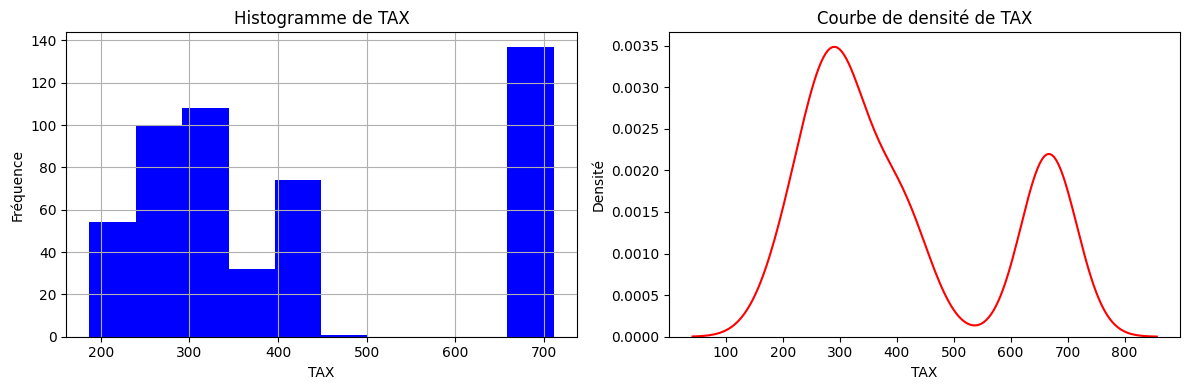

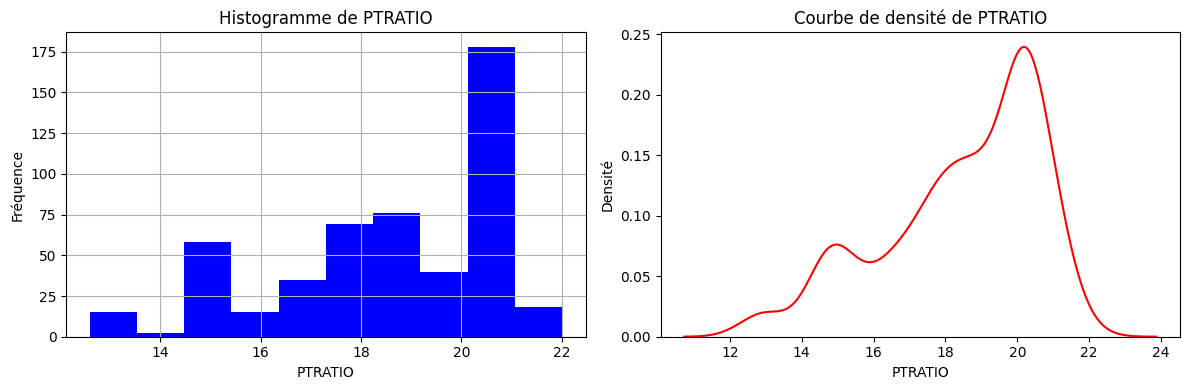

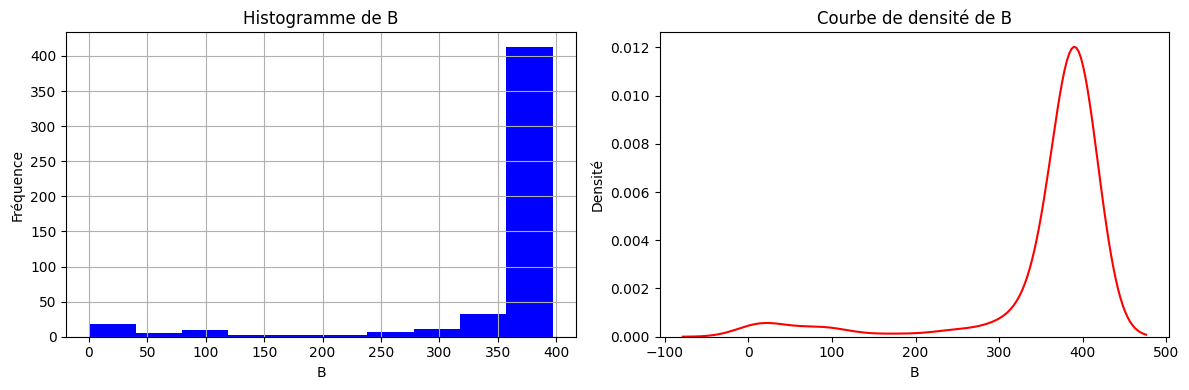

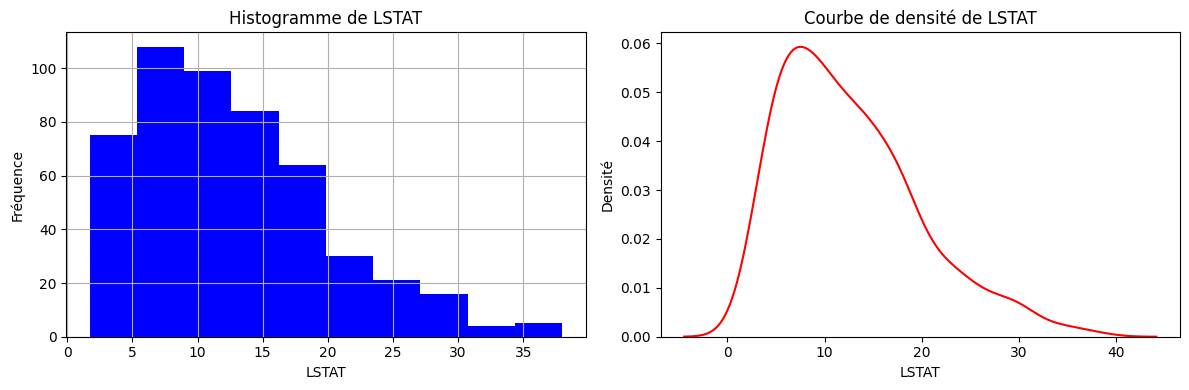

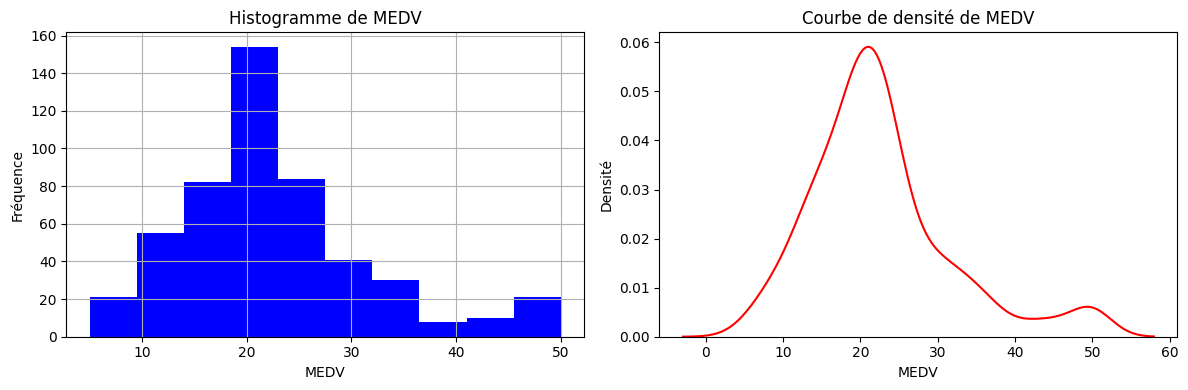

In [26]:
for colonne in donnees.columns:
    plt.figure(figsize=(12, 4))
    
    # Histogramme à gauche
    plt.subplot(1, 2, 1)
    donnees[colonne].hist(color="blue")
    plt.title(f"Histogramme de {colonne}")
    plt.xlabel(colonne)
    plt.ylabel("Fréquence")
    
    # Densité à droite
    plt.subplot(1, 2, 2)
    sns.kdeplot(donnees[colonne], color="red")
    plt.title(f"Courbe de densité de {colonne}")
    plt.xlabel(colonne)
    plt.ylabel("Densité")
    
    plt.tight_layout()
    plt.show()

### 3.3 Détection des valeurs aberrantes (Outliers)

L'utilisation de boxplots permet d'identifier visuellement la présence de valeurs extrêmes pour chaque variable.

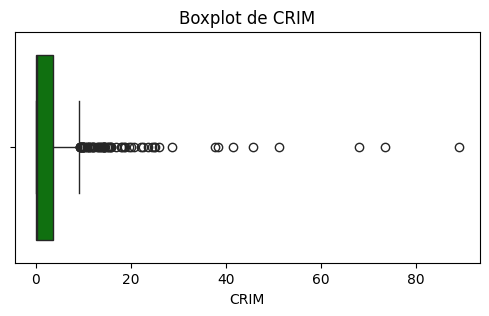

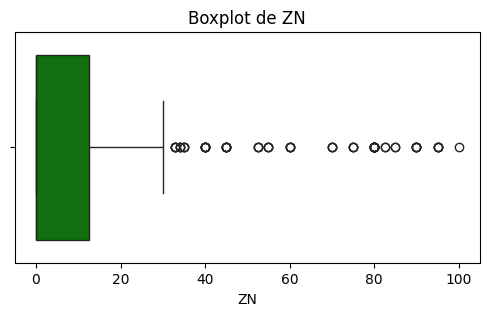

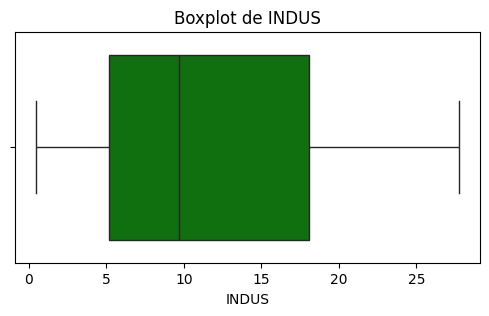

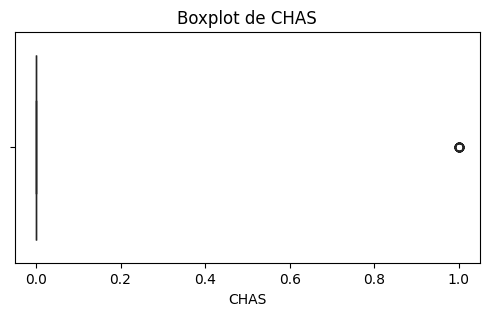

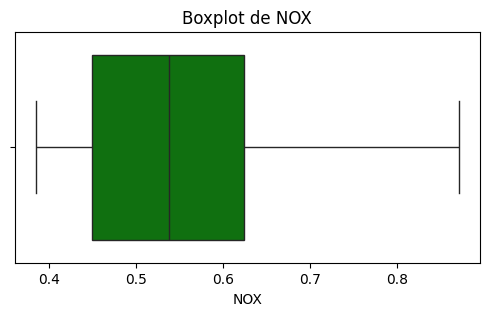

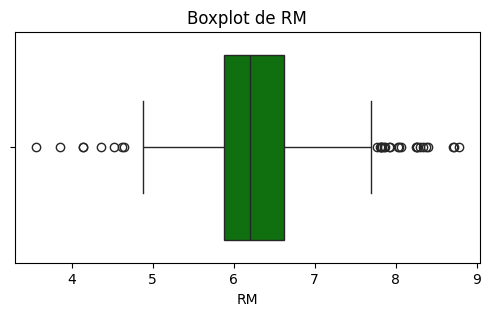

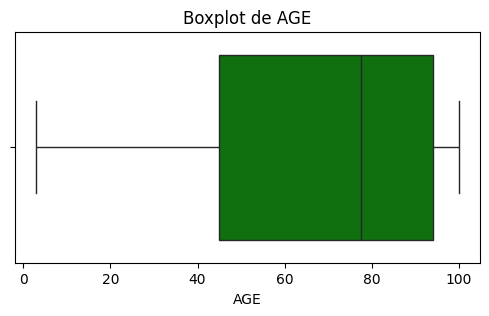

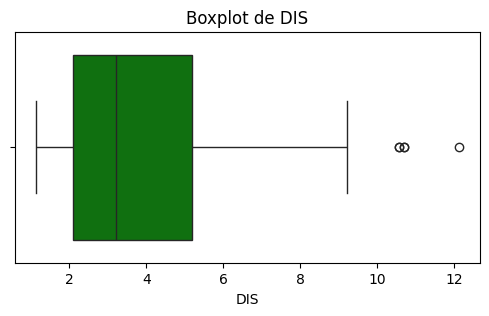

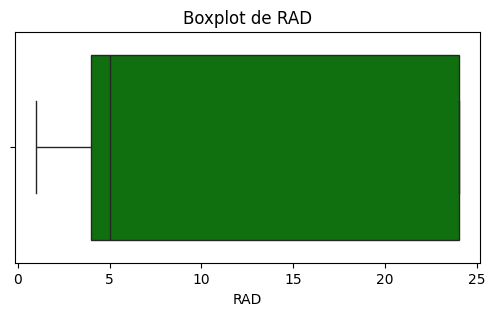

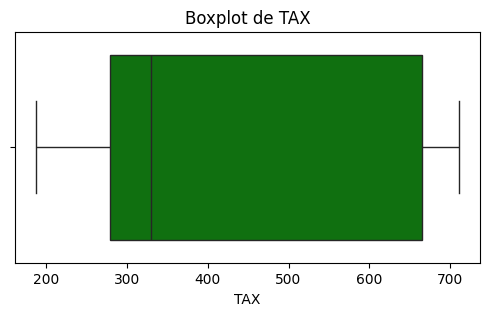

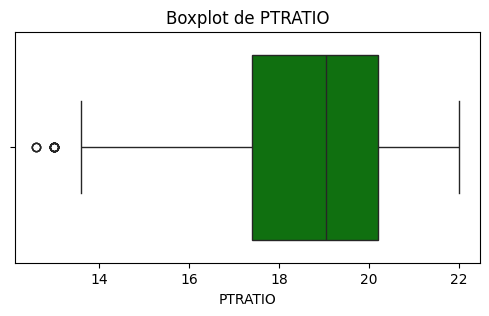

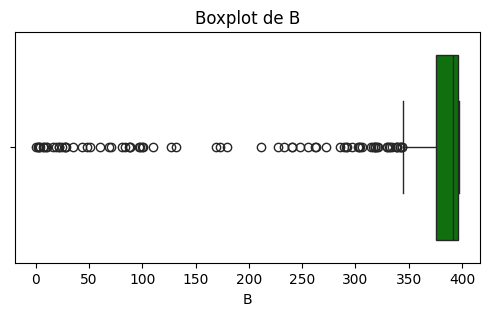

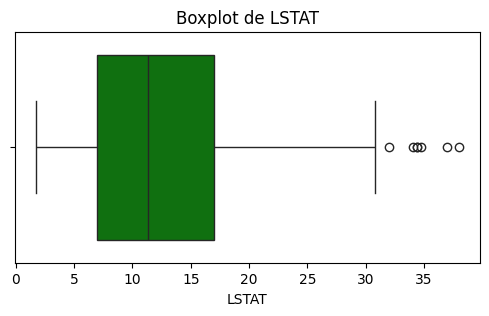

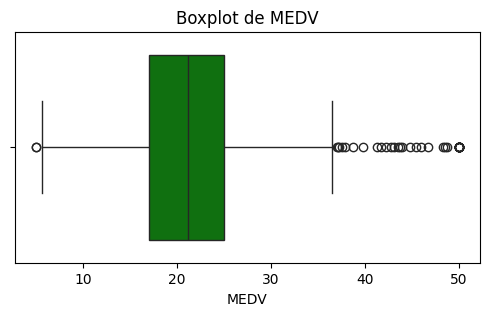

In [27]:
for colonne in donnees.columns:
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=donnees, x=colonne, color="green")
    plt.title(f"Boxplot de {colonne}")
    plt.xlabel(colonne)
    plt.show()

### 3.4 Analyse des corrélations

Maintenant que nous avons étudié chaque variable individuellement, nous analysons les relations qu'elles entretiennent entre elles, et surtout avec notre variable cible (`MEDV`).

Nous calculons la matrice de corrélation de Pearson, visualisée à l'aide d'une carte de chaleur :
* Une valeur proche de **1** → forte corrélation positive.
* Une valeur proche de **-1** → forte corrélation négative.
* Une valeur proche de **0** → absence de corrélation linéaire.

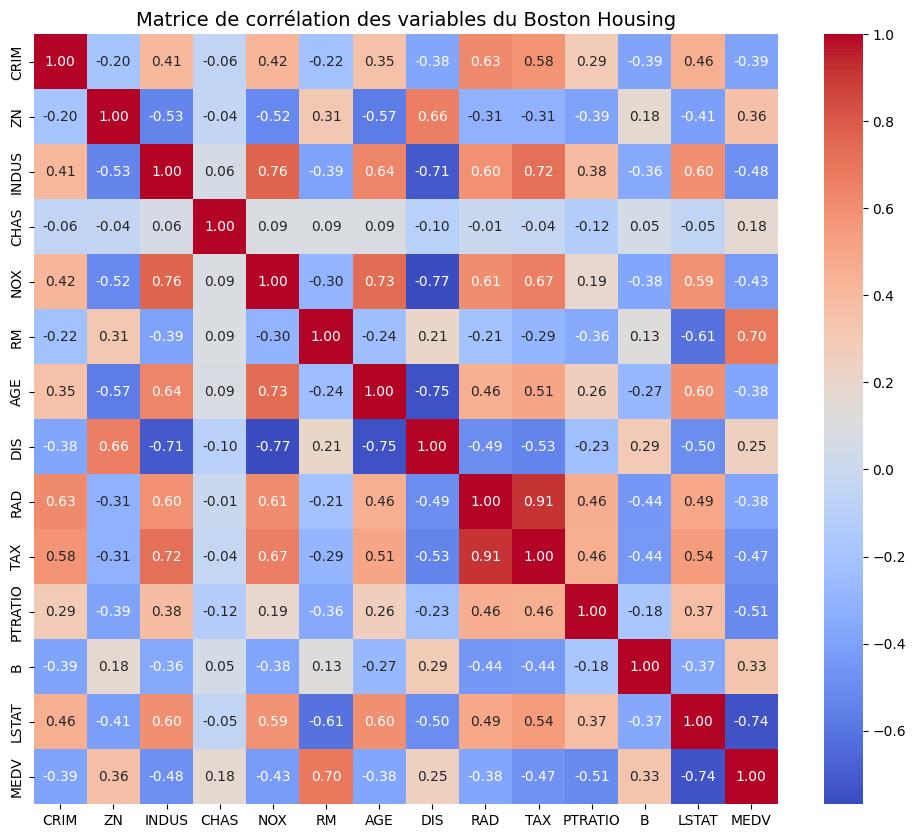

In [28]:
# Calcul de la matrice de corrélation
correlation = donnees.corr(numeric_only=True)

# Affichage en heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation des variables du Boston Housing", fontsize=14)
plt.show()

#### Interprétation de la matrice de corrélation

1. **Corrélations avec `MEDV` (prix médian) :**
   * Positives : `RM` (nombre moyen de pièces) est la plus fortement corrélée à la hausse (**r = 0.70**). Plus le logement est grand, plus son prix tend à être élevé.
   * Négatives : `LSTAT` (% de population défavorisée) présente la plus forte corrélation à la baisse (**r = −0.74**). Le ratio élèves/professeur (`PTRATIO`, −0.51) et la part d'industrie (`INDUS`, −0.48) tirent également les prix vers le bas.

2. **Multicolinéarité (corrélations entre variables explicatives) :**
   * Corrélation très forte (**0.91**) entre `RAD` (accessibilité aux autoroutes) et `TAX` (taux d'imposition foncière).
   * Un « bloc » pollution/urbanisation : `NOX` est fortement corrélé avec `INDUS` (**0.76**), `AGE` (**0.73**) et négativement avec `DIS` (**−0.77**).

### 3.5 Zoom sur les corrélations fortes et significatives

Pour chaque paire de variables dont la corrélation dépasse |0.5| et est statistiquement significative (p-value < 0.05), on calcule le R², son intervalle de confiance à 95 % (transformation de Fisher) et on trace le nuage de points avec la droite de régression.

--- Relation : CRIM vs RAD ---
r = 0.6255
R² = 0.3913
IC 95% du R² = [0.3242 , 0.4567]



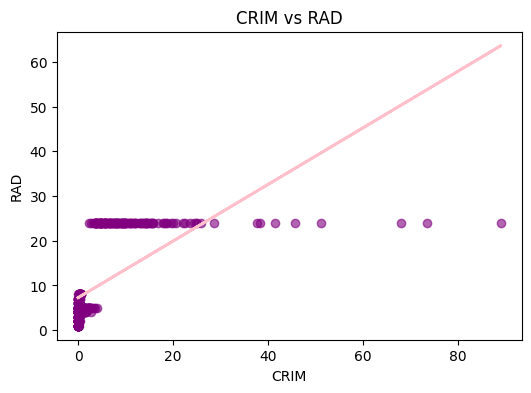

--- Relation : CRIM vs TAX ---
r = 0.5828
R² = 0.3396
IC 95% du R² = [0.2726 , 0.4065]



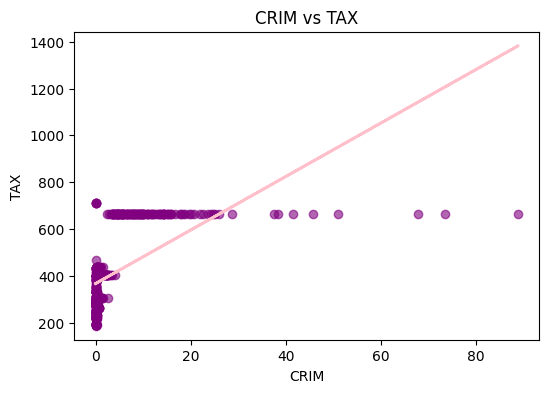

--- Relation : ZN vs INDUS ---
r = -0.5338
R² = 0.2850
IC 95% du R² = [0.3521 , 0.2195]



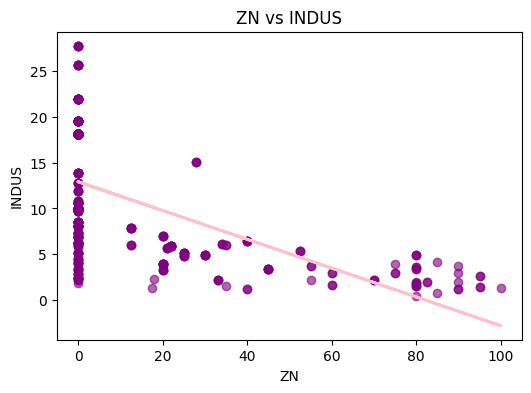

--- Relation : ZN vs NOX ---
r = -0.5166
R² = 0.2669
IC 95% du R² = [0.3338 , 0.2022]



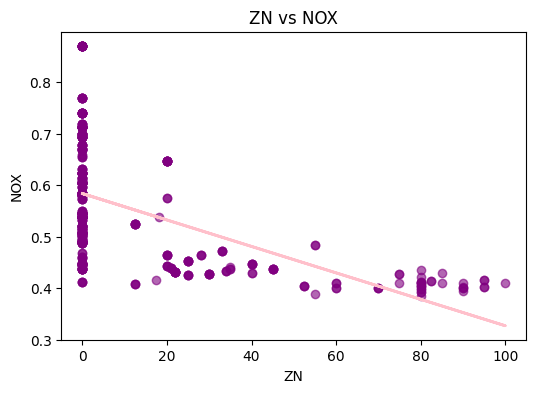

--- Relation : ZN vs AGE ---
r = -0.5695
R² = 0.3244
IC 95% du R² = [0.3914 , 0.2576]



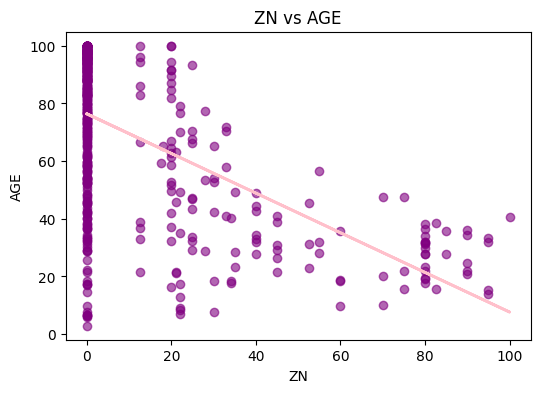

--- Relation : ZN vs DIS ---
r = 0.6644
R² = 0.4414
IC 95% du R² = [0.3754 , 0.5047]



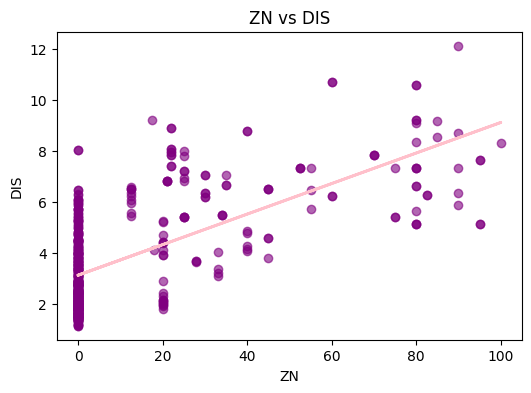

--- Relation : INDUS vs NOX ---
r = 0.7637
R² = 0.5832
IC 95% du R² = [0.5252 , 0.6364]



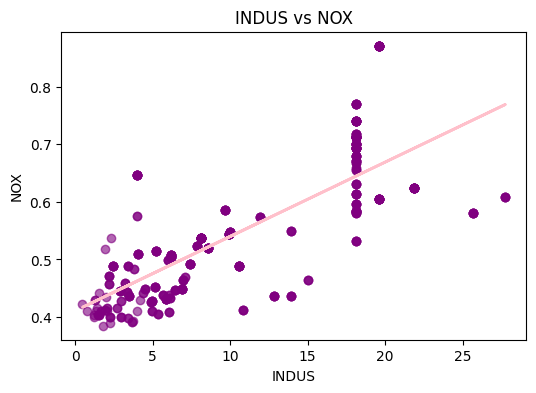

--- Relation : INDUS vs AGE ---
r = 0.6448
R² = 0.4157
IC 95% du R² = [0.3491 , 0.4802]



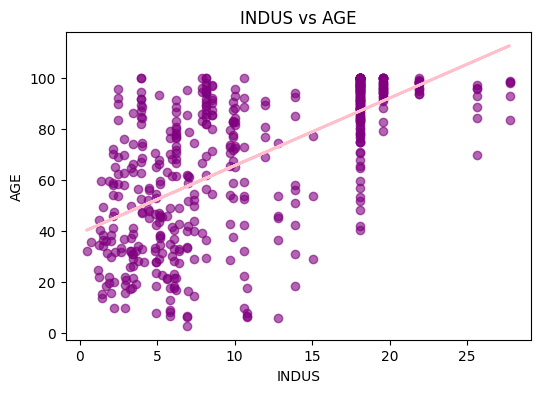

--- Relation : INDUS vs DIS ---
r = -0.7080
R² = 0.5013
IC 95% du R² = [0.5610 , 0.4378]



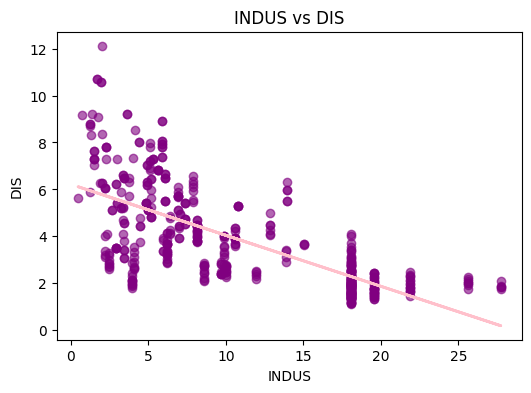

--- Relation : INDUS vs RAD ---
r = 0.5951
R² = 0.3542
IC 95% du R² = [0.2870 , 0.4207]



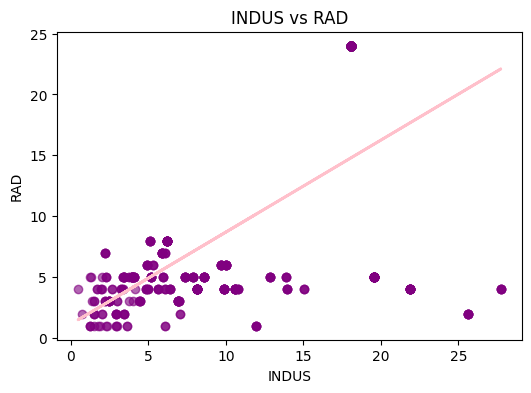

--- Relation : INDUS vs TAX ---
r = 0.7208
R² = 0.5195
IC 95% du R² = [0.4571 , 0.5779]



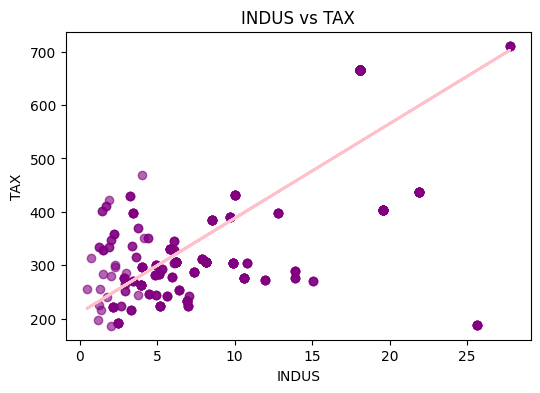

--- Relation : INDUS vs LSTAT ---
r = 0.6038
R² = 0.3646
IC 95% du R² = [0.2974 , 0.4309]



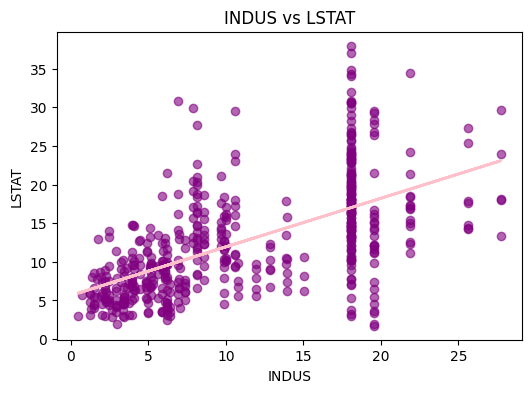

--- Relation : NOX vs AGE ---
r = 0.7315
R² = 0.5350
IC 95% du R² = [0.4736 , 0.5922]



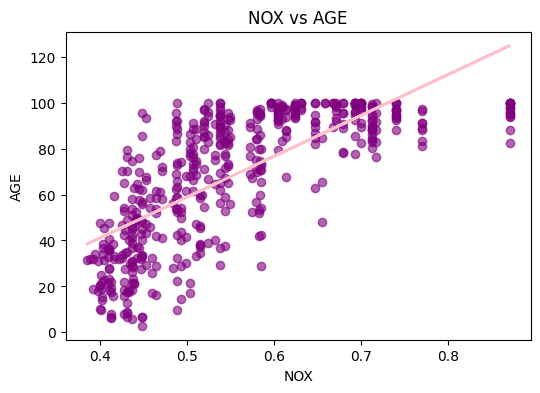

--- Relation : NOX vs DIS ---
r = -0.7692
R² = 0.5917
IC 95% du R² = [0.6441 , 0.5345]



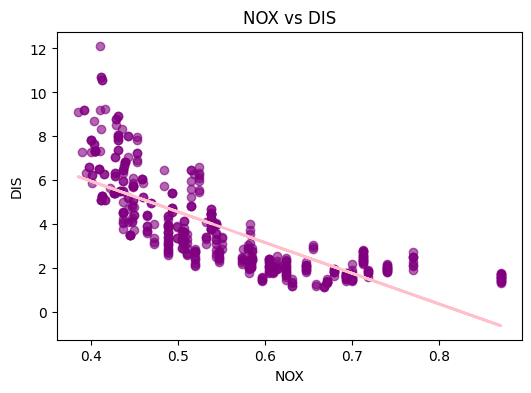

--- Relation : NOX vs RAD ---
r = 0.6114
R² = 0.3739
IC 95% du R² = [0.3067 , 0.4399]



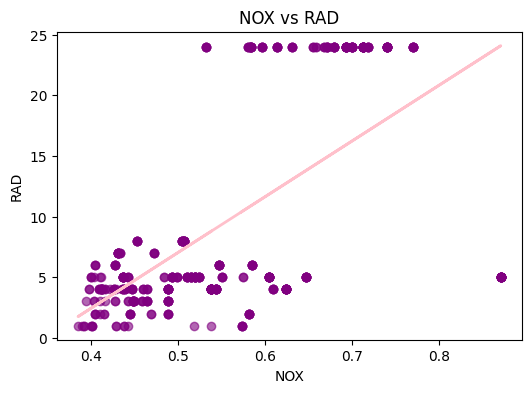

--- Relation : NOX vs TAX ---
r = 0.6680
R² = 0.4463
IC 95% du R² = [0.3804 , 0.5093]



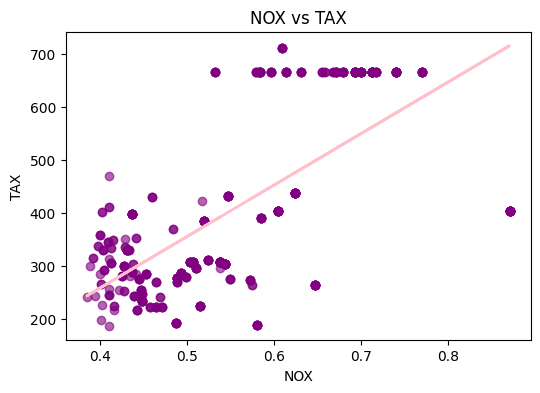

--- Relation : NOX vs LSTAT ---
r = 0.5909
R² = 0.3491
IC 95% du R² = [0.2820 , 0.4158]



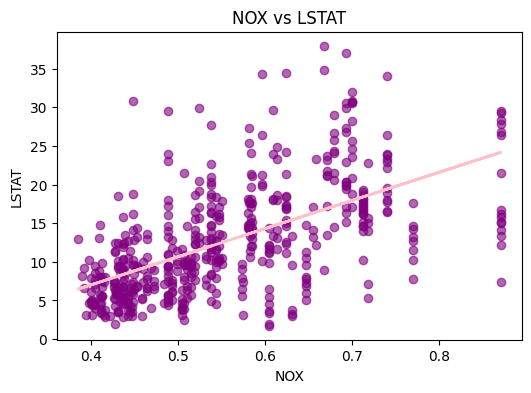

--- Relation : RM vs LSTAT ---
r = -0.6138
R² = 0.3768
IC 95% du R² = [0.4427 , 0.3096]



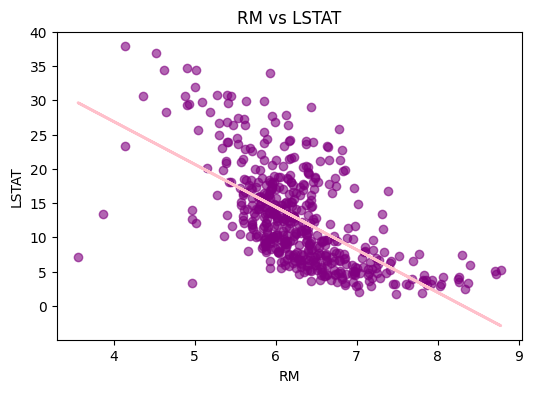

--- Relation : RM vs MEDV ---
r = 0.6954
R² = 0.4835
IC 95% du R² = [0.4192 , 0.5444]



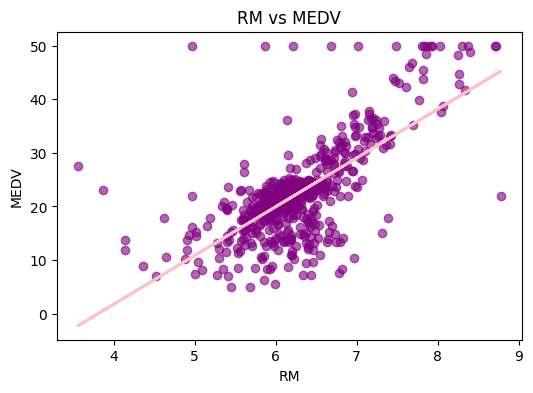

--- Relation : AGE vs DIS ---
r = -0.7479
R² = 0.5593
IC 95% du R² = [0.6146 , 0.4995]



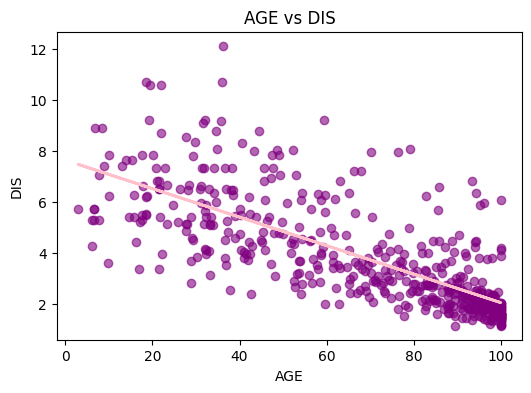

--- Relation : AGE vs TAX ---
r = 0.5065
R² = 0.2565
IC 95% du R² = [0.1924 , 0.3232]



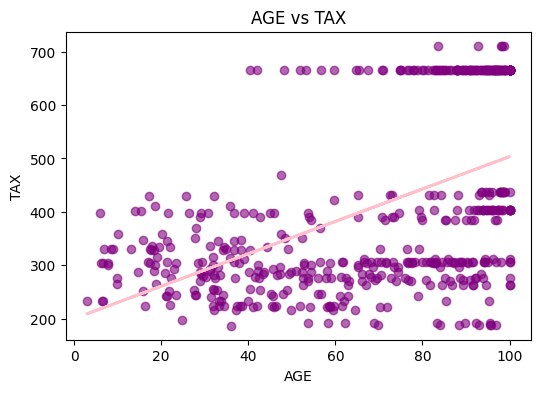

--- Relation : AGE vs LSTAT ---
r = 0.6023
R² = 0.3628
IC 95% du R² = [0.2956 , 0.4292]



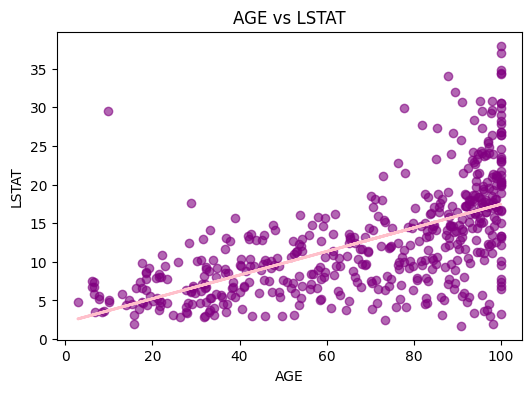

--- Relation : DIS vs TAX ---
r = -0.5344
R² = 0.2856
IC 95% du R² = [0.3528 , 0.2201]



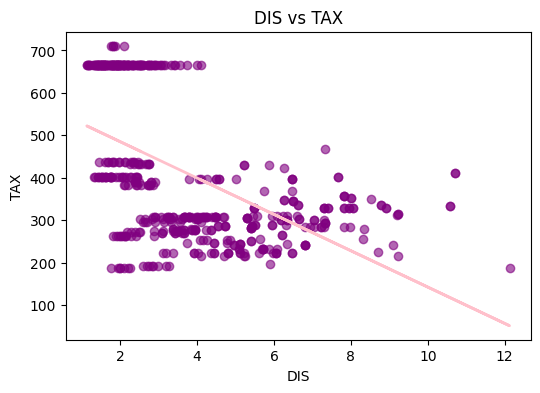

--- Relation : RAD vs TAX ---
r = 0.9102
R² = 0.8285
IC 95% du R² = [0.7992 , 0.8539]



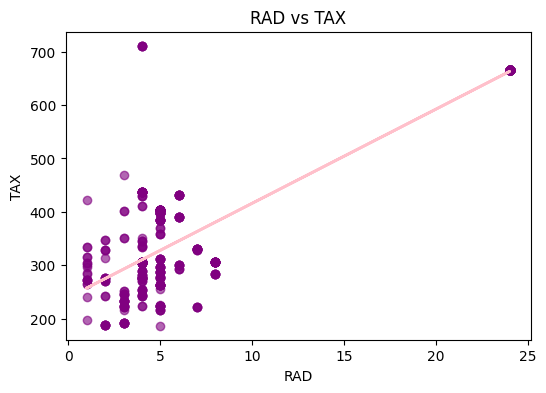

--- Relation : TAX vs LSTAT ---
r = 0.5440
R² = 0.2959
IC 95% du R² = [0.2300 , 0.3631]



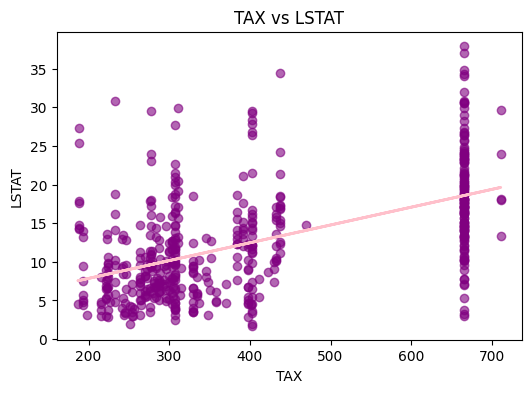

--- Relation : PTRATIO vs MEDV ---
r = -0.5078
R² = 0.2578
IC 95% du R² = [0.3246 , 0.1937]



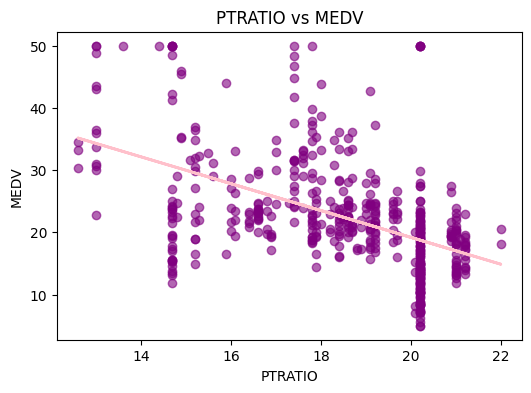

--- Relation : LSTAT vs MEDV ---
r = -0.7377
R² = 0.5441
IC 95% du R² = [0.6006 , 0.4833]



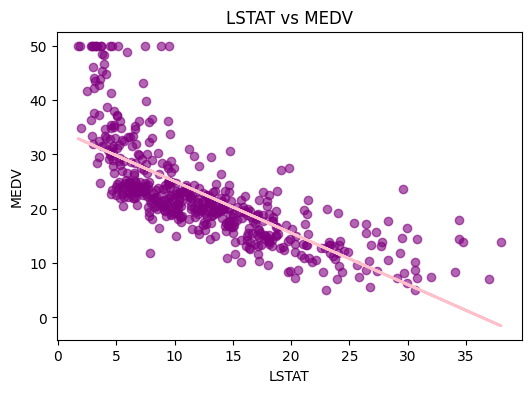

In [29]:
for i in range(len(colonnes)):
    for j in range(i+1, len(colonnes)):
        x = donnees[colonnes[i]].values
        y = donnees[colonnes[j]].values
        
        # Calcul du coefficient de corrélation r et p-value
        r_corr, p_value = st.pearsonr(x,y)
        
        # Filtre : on n'affiche que si la corrélation est forte et significative
        if p_value < 0.05 and abs(r_corr) > 0.5:
            r = np.corrcoef(x, y)[0,1]
            R2 = r**2
            
            # Calcul du IC95 de R2 (Transformation de Fisher)
            n = len(x)
            z = np.arctanh(r)
            erreur_std = 1 / np.sqrt(n-3)
            
            z_inf = z - 1.96 * erreur_std
            z_sup = z + 1.96 * erreur_std
            
            r_inf = np.tanh(z_inf)
            r_sup = np.tanh(z_sup)
            
            R2_inf = r_inf**2
            R2_sup = r_sup**2
            
            # Affichage des statistiques
            print(f"--- Relation : {colonnes[i]} vs {colonnes[j]} ---")
            print(f"r = {r:.4f}")
            print(f"R² = {R2:.4f}")
            print(f"IC 95% du R² = [{R2_inf:.4f} , {R2_sup:.4f}]\n")
            
            # Affichage du graphique
            plt.figure(figsize=(6, 4))
            plt.scatter(x, y, color="purple", alpha=0.6)
            
            # Droite de régression
            a, b = np.polyfit(x, y, 1)
            plt.plot(x, a*x + b, color="pink", linewidth=2)
            
            plt.title(f"{colonnes[i]} vs {colonnes[j]}")
            plt.xlabel(colonnes[i])
            plt.ylabel(colonnes[j])
            plt.show()

### 3.6 Extraction mathématique des variables clés

La matrice de corrélation nous a donné une intuition visuelle. On extrait ici de façon programmatique les 3 variables ayant le plus d'impact (positif ou négatif) sur le prix (`MEDV`).

In [30]:
# Extraction des corrélations par rapport à la cible
corr_medv = donnees.corr(numeric_only=True)["MEDV"].drop("MEDV")

# Tri par valeur absolue décroissante pour trouver les plus fortes relations
top3 = corr_medv.abs().sort_values(ascending=False).head(3)

print("--- Top 3 des variables les plus influentes (en valeur absolue) ---")
print(top3)
print("\n")

# Affichage avec les signes réels pour comprendre le sens de l'impact
print("--- Valeurs réelles (impact positif ou négatif) ---")
print(corr_medv.loc[top3.index])

--- Top 3 des variables les plus influentes (en valeur absolue) ---
LSTAT      0.737663
RM         0.695360
PTRATIO    0.507787
Name: MEDV, dtype: float64


--- Valeurs réelles (impact positif ou négatif) ---
LSTAT     -0.737663
RM         0.695360
PTRATIO   -0.507787
Name: MEDV, dtype: float64


### 3.7 Matrice de Variance-Covariance

On calcule la matrice de variance-covariance :
* La **diagonale** représente la variance de chaque variable (sa dispersion).
* Les **autres cases** représentent la covariance entre deux variables (comment elles varient ensemble).

> **Attention :** Contrairement à la corrélation, la covariance n'est pas standardisée ; les valeurs dépendent fortement des unités de mesure. La heatmap sera visuellement dominée par les variables aux plus grandes échelles, ce qui confirme la nécessité d'une standardisation avant la modélisation.

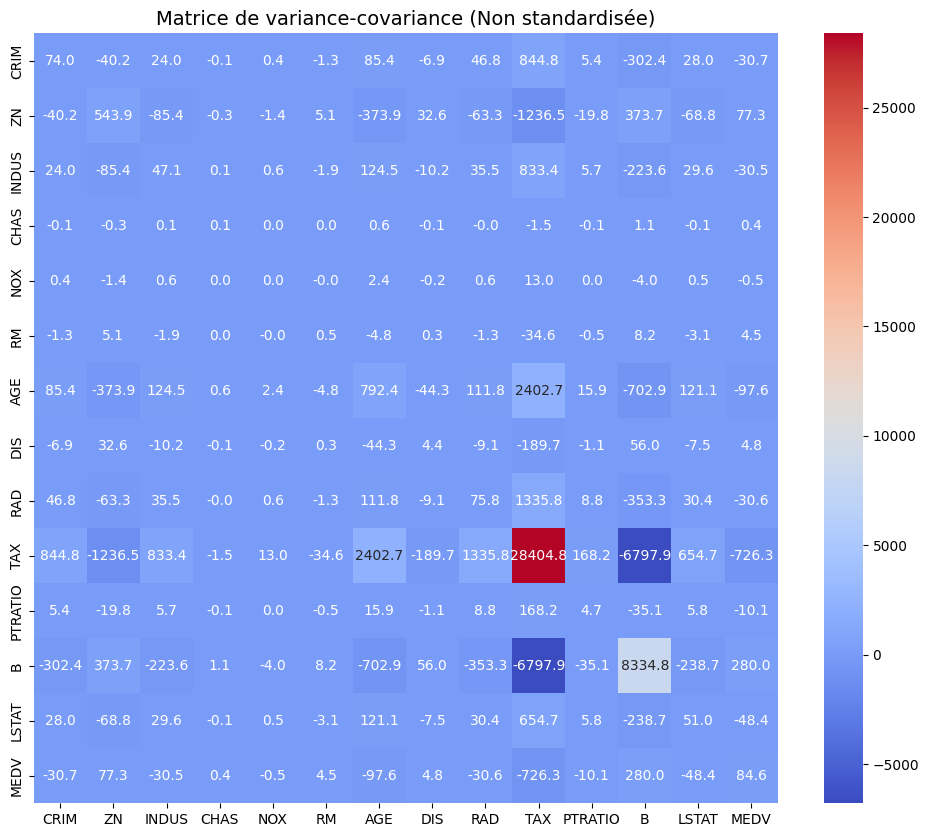

In [31]:
# Calcul de la matrice variance-covariance
m_covariance = donnees.cov(numeric_only=True)

# Affichage en heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(m_covariance, annot=True, cmap="coolwarm", fmt=".1f") 
plt.title("Matrice de variance-covariance (Non standardisée)", fontsize=14)
plt.show()

#### Conclusion : Covariance vs Corrélation

L'analyse confirme nos observations précédentes tout en mettant en évidence une limite statistique importante :

* **Sens d'évolution (le signe) :**
  * *Positive :* les variables évoluent ensemble (ex : `RAD`–`TAX`, `RM`–`MEDV`).
  * *Négative :* elles évoluent en sens opposé (ex : `LSTAT`–`MEDV`, `NOX`–`DIS`).
* **Limite de la covariance :** elle dépend entièrement des unités de mesure, rendant toute comparaison directe entre valeurs impossible. La **corrélation** — qui normalise la covariance sur [−1, 1] — reste le meilleur outil pour comparer la force des relations.

## 4. Analyse en Composantes Principales (ACP)

Nous avons vu qu'il existe une forte multicolinéarité entre certaines variables. L'ACP va nous permettre de :
1. Réduire la dimensionnalité du jeu de données.
2. Créer de nouvelles variables indépendantes (non corrélées entre elles).

L'ACP est très sensible aux unités de mesure. Il est obligatoire de standardiser les variables (moyenne = 0, écart-type = 1) avant de l'appliquer. La variable cible (`MEDV`) est retirée car l'ACP ne porte que sur les features.

### 4.1 Standardisation et calcul de l'ACP

On isole les variables explicatives, on les standardise avec `StandardScaler`, puis on applique l'ACP. On affiche la part de variance expliquée par chacune des trois premières composantes.

In [32]:
# 1. Isolation des variables explicatives (On enlève le prix)
donnees_sans_medv = donnees.drop(columns=["MEDV"])

# 2. Standardisation des variables
scaler = StandardScaler()
donnees_stand = scaler.fit_transform(donnees_sans_medv)

# 3. Calcul de l'ACP sur les données standardisées
pca = PCA()
pca.fit(donnees_stand)

# Récupération des valeurs clés
valeurs_propres = pca.explained_variance_
vecteurs_propres = pca.components_
variance_expliquee = pca.explained_variance_ratio_

print("Variance expliquée par les 3 premières composantes :")
print(f"Composante 1 : {variance_expliquee[0]*100:.2f}%")
print(f"Composante 2 : {variance_expliquee[1]*100:.2f}%")
print(f"Composante 3 : {variance_expliquee[2]*100:.2f}%")

Variance expliquée par les 3 premières composantes :
Composante 1 : 47.13%
Composante 2 : 11.03%
Composante 3 : 9.56%


### 4.2 Choix du nombre de composantes principales

Pour déterminer combien de composantes conserver, on confronte deux méthodes :
1. Le critère du coude (Scree Plot) : on observe une cassure après la 2ᵉ composante, idéal pour une visualisation 2D.
2. Le seuil de variance cumulée : pour conserver ~80 % de l'information, il faut retenir 5 composantes.

Dans une optique de modélisation (Machine Learning), nous retenons donc **5 composantes**.

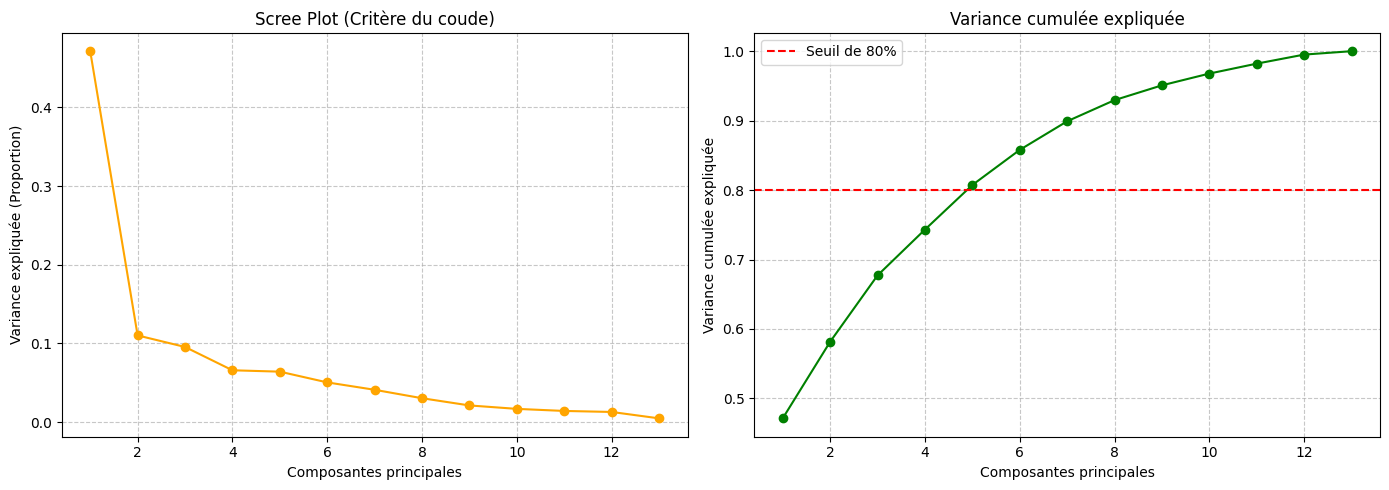

In [33]:
plt.figure(figsize=(14, 5))

# Graphique 1 : Scree Plot (Règle du coude)
plt.subplot(1, 2, 1)
plt.plot(range(1, len(variance_expliquee) + 1), variance_expliquee, color="orange", marker='o')
plt.xlabel("Composantes principales")
plt.ylabel("Variance expliquée (Proportion)")
plt.title("Scree Plot (Critère du coude)")
plt.grid(True, linestyle='--', alpha=0.7)

# Graphique 2 : Variance Cumulée (Seuil des 80%)
variance_cumulee = np.cumsum(variance_expliquee)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(variance_cumulee) + 1), variance_cumulee, color='green', marker='o')
plt.axhline(y=0.80, color='r', linestyle='--', label="Seuil de 80%")
plt.xlabel('Composantes principales')
plt.ylabel('Variance cumulée expliquée')
plt.title('Variance cumulée expliquée')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 4.3 Cercle des corrélations (Interprétation des composantes)

Même si nous retenons 5 composantes pour le modèle, on visualise les deux premières (PC1 et PC2) via le cercle des corrélations pour comprendre ce que ces axes artificiels représentent.
* Plus une flèche s'approche du bord du cercle, plus la variable est bien représentée par cet axe.
* Des flèches proches et dans la même direction indiquent des variables corrélées.

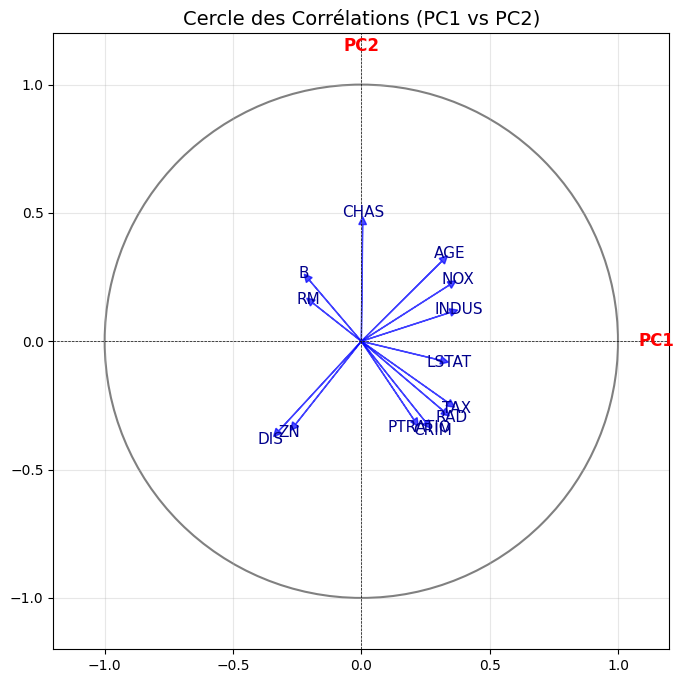

In [34]:
# Récupération des composantes principales
composantes_pr = pca.components_

plt.figure(figsize=(8, 8))

plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')

# Tracé du cercle de rayon 1
cercle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='-', linewidth=1.5)
plt.gca().add_artist(cercle)

# Ajout des flèches et des noms de variables
for i in range(len(donnees_sans_medv.columns)):
    plt.arrow(0, 0, composantes_pr[0, i], composantes_pr[1, i], 
              color='b', alpha=0.7, head_width=0.03, head_length=0.03)
    plt.text(composantes_pr[0, i] * 1.1, composantes_pr[1, i] * 1.1, 
             donnees_sans_medv.columns[i], color='darkblue', ha='center', va='center', fontsize=11)

plt.text(1.15, 0, 'PC1', color='red', ha='center', va='center', fontsize=12, fontweight='bold')
plt.text(0, 1.15, 'PC2', color='red', ha='center', va='center', fontsize=12, fontweight='bold')

plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.title("Cercle des Corrélations (PC1 vs PC2)", fontsize=14)
plt.grid(alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

**Interprétation des axes :**

En observant la direction des flèches, nous pouvons donner une signification concrète à nos deux premières composantes principales :

* **L'axe horizontal (PC1) : Le niveau socio-économique et d'urbanisation.** Il oppose les quartiers avec un fort taux de population défavorisée (`LSTAT`), de criminalité (`CRIM`) et de pollution (`NOX`) situés sur la droite, aux quartiers plus aisés sur la gauche. Il mesure donc le niveau global de richesse ou de défavorisation des quartiers.

* **L'axe vertical (PC2) : L'âge et la structure de l'habitat.**
  Il est fortement influencé par des variables comme l'âge des bâtiments (`AGE`) ou le nombre de pièces (`RM`). Il permet de différencier les types d'habitations et leur ancienneté.

### 4.4 Projection des observations (les quartiers)

Maintenant que nous comprenons la signification de PC1 (niveau socio-économique) et PC2 (âge/habitat), on projette les 506 quartiers de Boston sur ce plan 2D pour observer leur répartition et identifier visuellement les outliers.

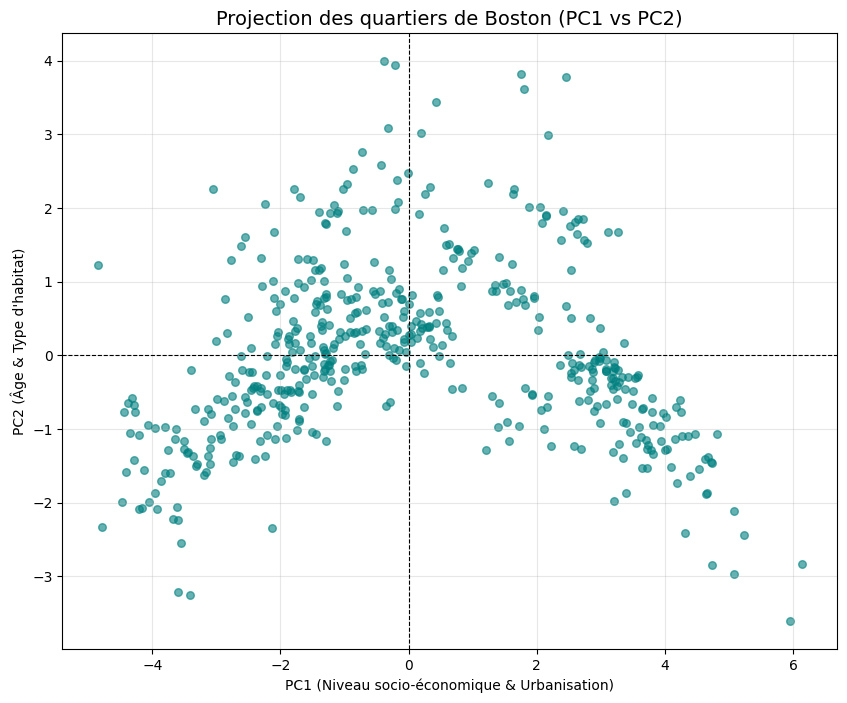

In [35]:
# Calcul des coordonnées des individus sur les composantes
pc_scores = pca.transform(donnees_stand)

plt.figure(figsize=(10, 8))
plt.scatter(pc_scores[:, 0], pc_scores[:, 1], alpha=0.6, s=30, color='teal')

# Ajout des axes (0,0) pour faciliter la lecture des quadrants
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')

plt.xlabel("PC1 (Niveau socio-économique & Urbanisation)")
plt.ylabel("PC2 (Âge & Type d'habitat)")
plt.title("Projection des quartiers de Boston (PC1 vs PC2)", fontsize=14)
plt.grid(alpha=0.3)
plt.show()

**Analyse du nuage de points et détection d'outliers :**

La majorité des quartiers se concentrent au centre du graphique, ce qui représente des quartiers "moyens". Cependant, nous observons plusieurs points qui s'éloignent fortement du groupe principal (les outliers) :

* **Outliers à l'extrême droite (`PC1 > 5`) :** Ces points isolés correspondent à des quartiers en forte difficulté socio-économique (fort taux de pauvreté, potentiellement très industrialisés et pollués).
* **Outliers à l'extrême gauche (`PC1 < -4`) :** Ces quartiers très éloignés sur la gauche représentent les zones les plus favorisées et résidentielles de Boston.
* **Outliers en haut (`PC2 > 4`) :** Ces points correspondent à des quartiers constitués de logements particulièrement anciens par rapport au reste de la ville.

## 5. Modélisation : Régression Linéaire Multiple

Suite à notre analyse exploratoire (heatmap), nous retenons les **5 variables** les plus corrélées avec `MEDV` :
* `LSTAT` — % de population défavorisée (r = −0.74)
* `RM` — Nombre moyen de pièces (r = 0.70)
* `PTRATIO` — Ratio élèves/professeur (r = −0.51)
* `INDUS` — Part d'industrie non-commerciale (r = −0.48)
* `TAX` — Taux d'imposition foncière (r = −0.47)

Ce choix est directement issu de l'EDA, ce qui assure une cohérence entre l'analyse exploratoire et la modélisation.

### 5.1 Sélection des variables et séparation Train / Test

On isole les 5 variables explicatives et la variable cible, puis on divise le jeu de données en ensemble d'entraînement (**80 %**) et de test (**20 %**) avec `random_state=50` pour la reproductibilité.

In [36]:
# Variables explicatives issues de l'EDA (top 5 corrélations avec MEDV)
variables_pred = donnees[["RM", "LSTAT", "PTRATIO", "INDUS", "TAX"]]
variable_cible = donnees["MEDV"]

# Séparation Train / Test
X_entrainement, X_test, Y_entrainement, Y_test = train_test_split(
    variables_pred, variable_cible, test_size=0.2, random_state=50
)

### 5.2 Entraînement du modèle et calcul des performances

On entraîne un modèle de régression linéaire avec `scikit-learn` et on évalue ses performances sur les données de test (données inédites pour le modèle) via le R², le R² ajusté et le RMSE.

In [37]:
# Initialisation et entraînement du modèle
model = LinearRegression()
model.fit(X_entrainement, Y_entrainement)

# Prédictions sur l'ensemble de test
Y_pred = model.predict(X_test)

# Calcul des métriques d'évaluation
r2 = model.score(X_test, Y_test)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))

# Calcul du R² ajusté
n = len(Y_test)
p = X_test.shape[1]
r2_ajuste = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print(f"--- Performances du modèle sur l'ensemble de Test ---")
print(f"R² du modèle        : {r2:.4f}")
print(f"R² ajusté du modèle : {r2_ajuste:.4f}")
print(f"RMSE du modèle      : {rmse:.2f}")

--- Performances du modèle sur l'ensemble de Test ---
R² du modèle        : 0.5799
R² ajusté du modèle : 0.5580
RMSE du modèle      : 5.68


### 5.3 Analyse de la significativité des variables (Statsmodels)

Pour s'assurer que les variables retenues ont un réel impact prédictif, on analyse les coefficients et leurs **p-values** avec `statsmodels`. Une p-value supérieure à 0.05 indique que la variable n'est pas statistiquement significative dans ce modèle.

In [38]:
# Ajout de la constante (ordonnée à l'origine) requise par statsmodels
X_entrainement_sm = sm.add_constant(X_entrainement)

# Entraînement du modèle OLS (Ordinary Least Squares)
model_sm = sm.OLS(Y_entrainement, X_entrainement_sm).fit()

# Affichage du résumé statistique
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.701
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                     186.9
Date:                Sat, 25 Apr 2026   Prob (F-statistic):          4.78e-102
Time:                        18:14:18   Log-Likelihood:                -1229.7
No. Observations:                 404   AIC:                             2471.
Df Residuals:                     398   BIC:                             2495.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         16.2710      4.440      3.665      0.0

### 5.4 Visualisation : Valeurs réelles vs Valeurs prédites

On trace les prédictions face aux vraies valeurs. Plus les points se rapprochent de la diagonale rouge (y = x), meilleures sont les prédictions du modèle.

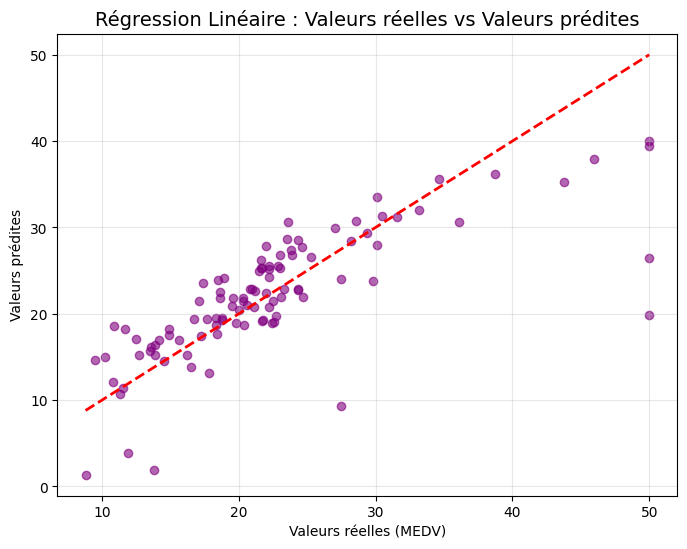

In [39]:
plt.figure(figsize=(8, 6))
plt.scatter(Y_test, Y_pred, color="purple", alpha=0.6)

# Tracé de la diagonale parfaite (y = x)
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color="red", linewidth=2, linestyle='--')

plt.title("Régression Linéaire : Valeurs réelles vs Valeurs prédites", fontsize=14)
plt.xlabel("Valeurs réelles (MEDV)")
plt.ylabel("Valeurs prédites")
plt.grid(alpha=0.3)
plt.show()

### 5.5 Interprétation des résultats

L'analyse des coefficients du modèle révèle :
* **`RM` (Nombre de pièces) :** coefficient positif fort — plus le logement est grand, plus `MEDV` augmente.
* **`LSTAT` (Statut socio-économique) :** coefficient négatif fort — une forte proportion de ménages défavorisés fait baisser la valeur des biens.
* **`TAX` (Taux d'imposition) :** coefficient négatif — des taxes élevées tirent le prix vers le bas.

**Variables superflues :** `INDUS` et `PTRATIO` présentent des p-values proches ou supérieures à **0.05** dans ce modèle multiple, ce qui suggère que leur impact individuel est moins significatif une fois les autres variables contrôlées.

## 6. Régression sur Composantes Principales (PCR)

Pour finaliser notre étude, on teste une approche différente : la **PCR (Principal Component Regression)**. Au lieu des variables originales corrélées entre elles, on utilise les composantes principales issues de l'ACP comme prédicteurs.

**Avantages attendus :**
* Réduction de la multicolinéarité : les composantes sont orthogonales (non corrélées).
* Stabilité des coefficients : le modèle est plus robuste aux petites variations des données.
* Réduction de l'overfitting : en simplifiant l'espace des données.

### 6.1 Implémentation (sans data leakage)

On applique scrupuleusement l'ordre correct : split d'abord, puis standardisation et ACP fittées uniquement sur le train, et appliquées en `transform` seulement sur le test — pour éviter toute fuite d'information.

In [40]:
X_all = donnees.drop(columns=["MEDV"])
y_all = donnees["MEDV"]
X_tr_raw, X_te_raw, y_train_pcr, y_test_pcr = train_test_split(
    X_all, y_all, test_size=0.2, random_state=50
)

scaler_pcr = StandardScaler()
X_tr_scaled = scaler_pcr.fit_transform(X_tr_raw)
X_te_scaled = scaler_pcr.transform(X_te_raw)

pca_pcr = PCA(n_components=5)
X_train_pca = pca_pcr.fit_transform(X_tr_scaled)
X_test_pca  = pca_pcr.transform(X_te_scaled)

print(f"Variance expliquée par les 5 composantes : {pca_pcr.explained_variance_ratio_.sum()*100:.1f}%")

model_pcr = LinearRegression()
model_pcr.fit(X_train_pca, y_train_pcr)
y_pred_pcr = model_pcr.predict(X_test_pca)

r2_pcr   = model_pcr.score(X_test_pca, y_test_pcr)
rmse_pcr = np.sqrt(mean_squared_error(y_test_pcr, y_pred_pcr))

print("\n--- Résultats de la PCR (sans data leakage) ---")
print(f"R²   : {r2_pcr:.4f}")
print(f"RMSE : {rmse_pcr:.2f}")


Variance expliquée par les 5 composantes : 81.0%

--- Résultats de la PCR (sans data leakage) ---
R²   : 0.6094
RMSE : 5.48


On compare les deux approches sur les mêmes données (même split, même `random_state=50`), ce qui garantit une comparaison équitable et sans biais.

### 6.2 Comparaison des modèles et Conclusion

| Modèle | R² | RMSE |
| :--- | :---: | :---: |
| **Régression Linéaire Classique** (5 variables EDA) | *0.5799* | *5.68* |
| **PCR** (5 composantes, sans data leakage) | *0.6094* | *5.48* |

#### Analyse des résultats

La PCR est comparée équitablement ici : même split, même `random_state=50`, preprocessing uniquement sur le train. Les gains observés reflètent donc réellement l'apport de la réduction de dimensionnalité.

#### Compromis Performance vs Interprétabilité

Dans la régression classique, chaque coefficient se lit directement (ex : *«une pièce supplémentaire ajoute X k$ au prix»*). La PCR perd cette lisibilité car elle opère sur des mélanges mathématiques de variables. Elle reste cependant plus robuste face à la multicolinéarité.

**Conclusion :** Pour une prédiction de prix à Boston, la PCR offre un meilleur compromis performance/robustesse. Pour un usage nécessitant de l'explicabilité, la régression sur les variables EDA (`LSTAT`, `RM`, `PTRATIO`…) sera préférable.